Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 301s 696ms/step - accuracy: 0.8126 - loss: 0.4204 - val_accuracy: 0.6875 - val_loss: 0.9091 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 395ms/step - accuracy: 0.9392 - loss: 0.1535 - val_accuracy: 0.7500 - val_loss: 0.5672 - learning_rate: 1.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 393ms/step - accuracy: 0.9512 - loss: 0.1296 - val_accuracy: 0.9375 - val_loss: 0.2178 - learning_rate: 1.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 397ms/step - accuracy: 0.9537 - loss: 0.1187 - val_accuracy: 1.0000 - val_loss: 0.0832 - learning_rate: 1.0000e-04
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 380ms/step - accuracy: 0.9677 - loss: 0.0838 - val_accuracy: 0.7500 - val_loss: 0.3361 - learning_rate: 1.0000e-04
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 378ms/step - accuracy: 0.9666 - loss: 0.0851 - val_accuracy: 0.7500 - val_loss: 0.3377 - learning_rate: 1.0000e-04
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 374ms/step -

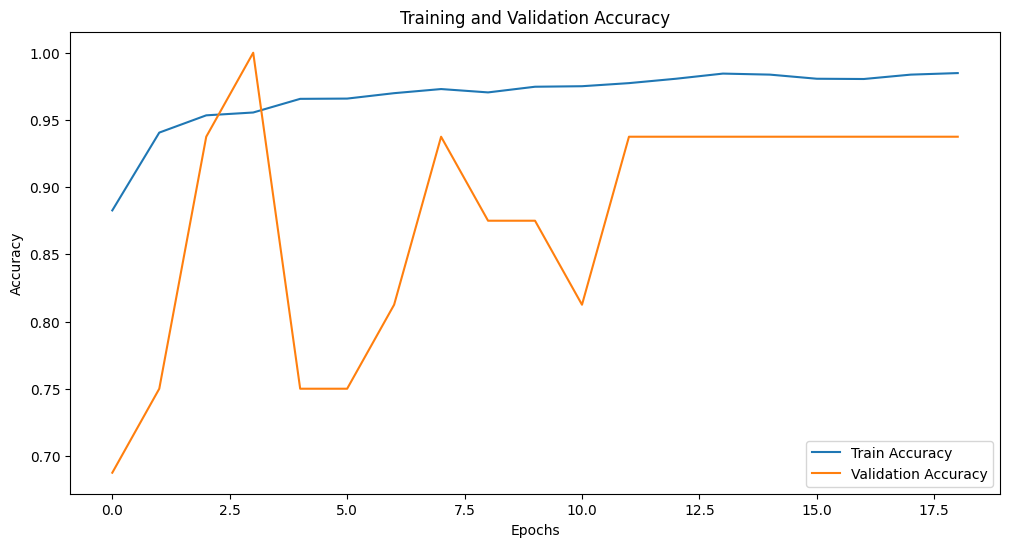

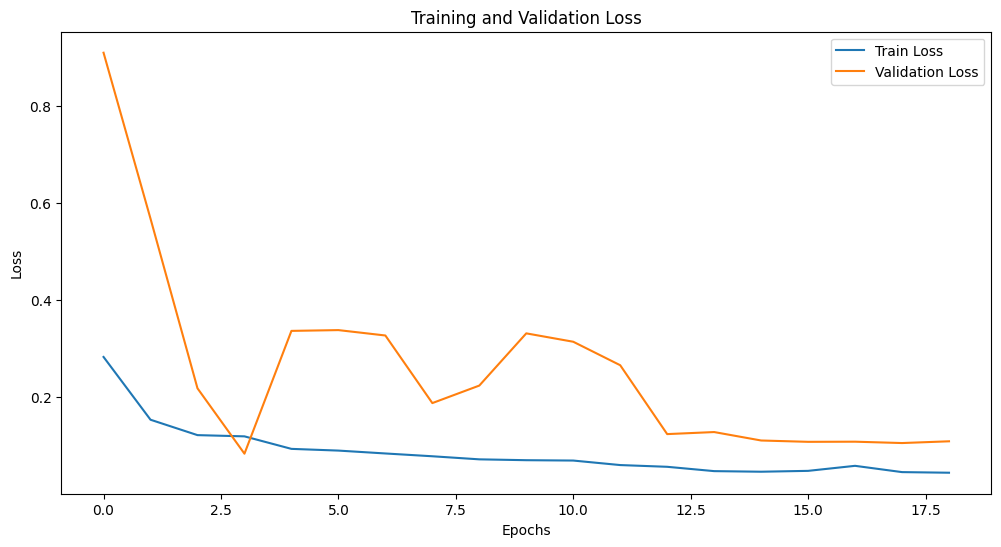

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 609ms/step - accuracy: 0.9314 - loss: 0.1575

Best Model Test Accuracy: 92.15%
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 863ms/step


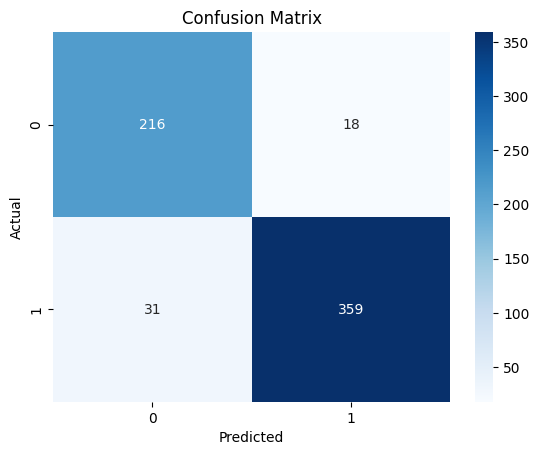

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.92      0.90       234
   PNEUMONIA       0.95      0.92      0.94       390

    accuracy                           0.92       624
   macro avg       0.91      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step


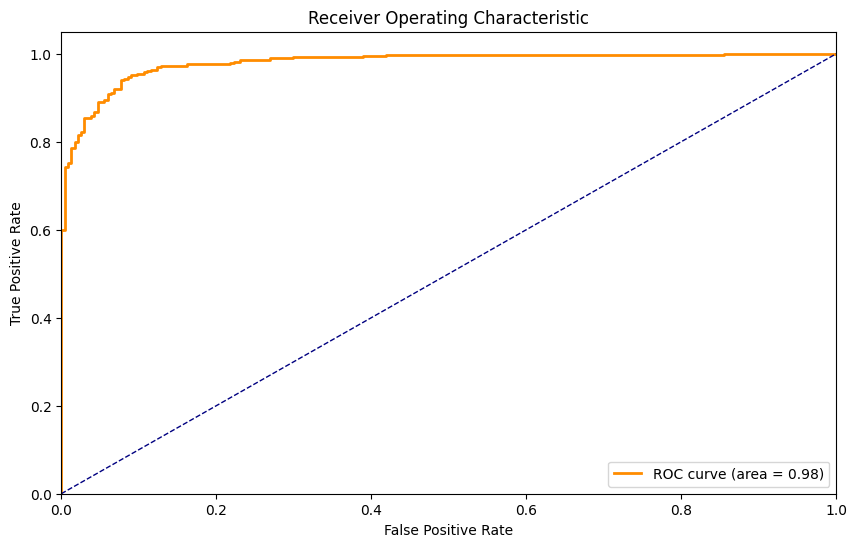

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Data Preparation
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
train_dir = base_dir + 'train/'
val_dir = base_dir + 'val/'
test_dir = base_dir + 'test/'

# Image Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators
batch_size = 32  # Reduced batch size
target_size = (128, 128)  # Reduced image size for better memory efficiency

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Build DenseNet201 Model
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the first few layers for transfer learning
base_model.trainable = True
for layer in base_model.layers[:250]:  # Unfreeze later layers
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Learning Rate Scheduler
def lr_schedule(epoch, lr):
    if epoch > 10:
        lr *= 0.5
    return lr

# Callbacks for EarlyStopping, LearningRateScheduler, and ModelCheckpoint
checkpoint_path = "best_densenet201_model.keras"
callbacks = [
    tf.keras.callbacks.LearningRateScheduler(lr_schedule),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Save the trained model
model_save_path = "pneumonia_detection_densenet201_model.h5"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

# Plotting Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation on Test Data
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Load the Best Model
best_model = load_model(checkpoint_path)
eval_results = best_model.evaluate(test_generator)
print(f"\nBest Model Test Accuracy: {eval_results[1] * 100:.2f}%")

# Confusion Matrix and Classification Report
predictions = (best_model.predict(test_generator) > 0.5).astype('int32')
true_classes = test_generator.classes

conf_matrix = confusion_matrix(true_classes, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predictions, target_names=test_generator.class_indices.keys()))

# ROC-AUC Curve
pred_probs = best_model.predict(test_generator).ravel()
roc_auc = roc_auc_score(true_classes, pred_probs)

fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
